In [26]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

from model_ranking import (
    UnetrWrapper,
    FeatureExtractor,
    load_h5,
    get_roi_slice,
)
from pytorch3dunet.unet3d.model import UNet2D, ResidualUNet2D
from pytorch3dunet.unet3d.predictor import PatchWisePredictor
from pytorch3dunet.datasets.utils import default_prediction_collate


In [27]:
from typing import Any, Dict
from torch.utils.data import ConcatDataset, DataLoader
from model_ranking import (
    semantic_loaders_type,
    loader_classes,
    Pytorch3DUnetTrainLoaderConfig,
    Pytorch3DUnetTestLoaderConfig,
    Pytorch3DUnetLoaderMetaConfig,
    Pytorch3DUnetSliceBuilderConfig,
)


def get_datasets(
    config: semantic_loaders_type,
):
    # get dataset class
    dataset_cls_str = config.dataset
    dataset_class = loader_classes(dataset_cls_str)
    datasets = dataset_class.create_datasets(config.model_dump(), phase="test")
    return datasets

def initialise_target_datasets(# pyright: ignore
    loader_config: Pytorch3DUnetLoaderMetaConfig,
):
    target_dataset_cfg = loader_config.create_config(
        output_dir="/g/kreshuk/talks/model_ranking/notebooks/model_selection/consistency/mitochondria/predictions",
        #output_dir=None,
        data_base_path="/scratch/talks/data",
        phase="test",
    )
    assert isinstance(
        target_dataset_cfg,
        (
            Pytorch3DUnetTrainLoaderConfig,
            Pytorch3DUnetTestLoaderConfig,
        ),
    ), f"Expected semantic loader config type, got {type(target_dataset_cfg).__name__}"
    target_datasets = get_datasets(target_dataset_cfg)
    target_dataset = target_datasets[0]
    #target_dataset  = ConcatDataset(target_datasets) # pyright: ignore
    collate_fn = default_prediction_collate
    target_dataloader = DataLoader(
        target_dataset, 
        batch_size=target_dataset_cfg.batch_size, 
        num_workers=target_dataset_cfg.num_workers, 
        pin_memory=True,
        collate_fn=collate_fn
    )
    # target_dataloader = DataLoader(# pyright: ignore
    #     target_dataset,# pyright: ignore
    #     batch_size=target_dataset_cfg.batch_size,
    #     shuffle=False,
    #     pin_memory=True,
    #     num_workers=target_dataset_cfg.num_workers,
    # )

    return target_dataset, target_dataloader# pyright: ignore

In [28]:
EPFL_loader_cfg: Pytorch3DUnetLoaderMetaConfig = Pytorch3DUnetLoaderMetaConfig(
        dataset="StandardHDF5Dataset",
        batch_size=10,
        num_workers=8,
        raw_internal_path="raw",
        label_internal_path="labels",
        global_normalization=True,
        #global_normalization=False,
        global_percentiles=None,
        file_paths=("/EPFL/test.h5",),
        roi=None,
        transformer={
            "raw": [
                {"name": "Normalize"},
                {"name": "ToTensor", "expand_dims": True},
            ],
            "label": [
                {"name": "ToTensor", "expand_dims": True},
            ],
        },
        slice_builder=Pytorch3DUnetSliceBuilderConfig(
            name="SliceBuilder",
            patch_shape=(1, 256, 256),
            stride_shape=(1, 256, 256),
            halo_shape=(0, 32, 32),
        ),
    )

dataset, dataloader = initialise_target_datasets(EPFL_loader_cfg)

2025-11-01 20:21:12,515 [MainThread] INFO HDF5Dataset - Loading test set from: /scratch/talks/data/EPFL/test.h5...
2025-11-01 20:21:12,518 [MainThread] INFO HDF5Dataset - Auto-calculated padding: [0, 0, 0] for patch_shape: (1, 256, 256) and volume_shape: (125, 480, 640)
2025-11-01 20:21:12,518 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 0.5599145293235779, global std: 0.11937469989061356
2025-11-01 20:21:12,738 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 32, 32)}
2025-11-01 20:21:12,740 [MainThread] INFO HDF5Dataset - Number of patches: 750


In [30]:
RtoE_NA_ckpt_path = "/g/kreshuk/talks/segmentation_ModelSelection/experiments/Rmito/BatchNorm/Rm_model_NA2/best_checkpoint.pytorch"
model_config: Dict[str, Any] = {
    "name": "UNet2D",
    "in_channels": 1,
    "out_channels": 1,
    "layer_order": "bcr",
    "f_maps": 32,
    "final_sigmoid": True,
    "is_segmentation": True,
    "dropout_prob": 0
}

RtoE_NA_model = UNet2D(**model_config)
_ = RtoE_NA_model.load_state_dict(torch.load(RtoE_NA_ckpt_path)["model_state_dict"])
#print(RtoE_NA_model)

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [33]:
RtoE_NA_model = RtoE_NA_model.to(device="cuda:0", dtype=torch.float32)
_ = RtoE_NA_model.eval()
preds_eval_mode = torch.empty((750, 1, 320, 320))
for i, (raw, _) in tqdm(enumerate(dataset)):
    raw = raw.to(device="cuda:0", dtype=torch.float32)
    preds_eval_mode[i] = RtoE_NA_model(raw) > 0.5

750it [00:03, 229.13it/s]


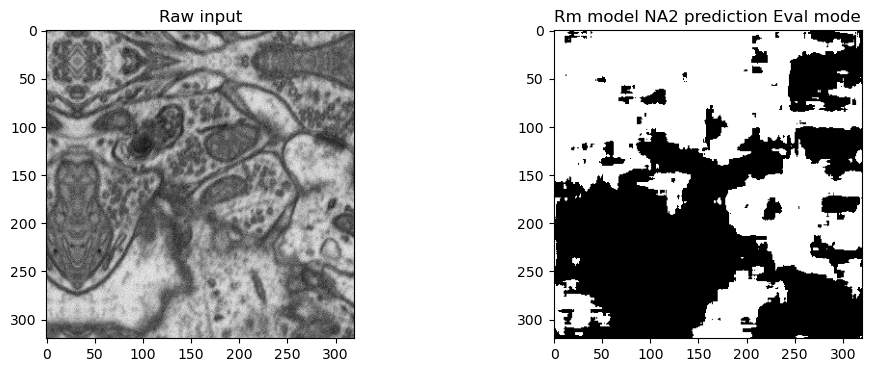

In [37]:
raw, label = dataset[0]
_, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].imshow(raw.numpy().squeeze(), cmap="gray")
axs[0].set_title("Raw input")
# axs[1].imshow(label.numpy().squeeze(), cmap="gray")
# axs[1].set_title("Ground truth")
axs[1].imshow(preds_eval_mode[0].numpy().squeeze(), cmap="gray")
axs[1].set_title("Rm model NA2 prediction Eval mode")
plt.show()

In [35]:
RtoE_NA_model = RtoE_NA_model.to(device="cuda:0", dtype=torch.float32)
_ = RtoE_NA_model.train()
preds_train_mode = torch.empty((750, 1, 320, 320))
for i, (raw, _) in tqdm(enumerate(dataset)):
    raw = raw.to(device="cuda:0", dtype=torch.float32)
    preds_train_mode[i] = RtoE_NA_model(raw) > 0.5

750it [00:03, 211.35it/s]


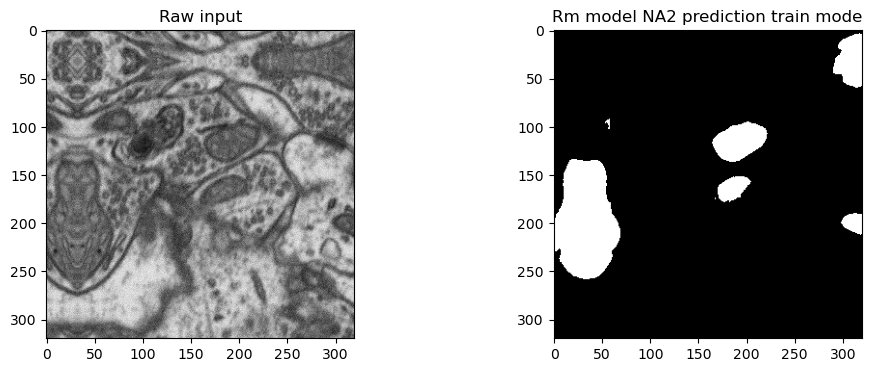

In [38]:
raw, label = dataset[0]
_, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].imshow(raw.numpy().squeeze(), cmap="gray")
axs[0].set_title("Raw input")
# axs[1].imshow(label.numpy().squeeze(), cmap="gray")
# axs[1].set_title("Ground truth")
axs[1].imshow(preds_train_mode[0].numpy().squeeze(), cmap="gray")
axs[1].set_title("Rm model NA2 prediction train mode")
plt.show()

In [8]:
prediction = torch.empty((750, 1, 320, 320))
for i, (raw, _) in tqdm(enumerate(dataloader)):
    raw = torch.squeeze(raw, dim=-3)
    raw = raw.to(device="cuda:0", dtype=torch.float32)
    prediction[i*10:i*10+raw.shape[0]] = RtoE_NA_model(raw) > 0.5


75it [00:02, 30.04it/s]


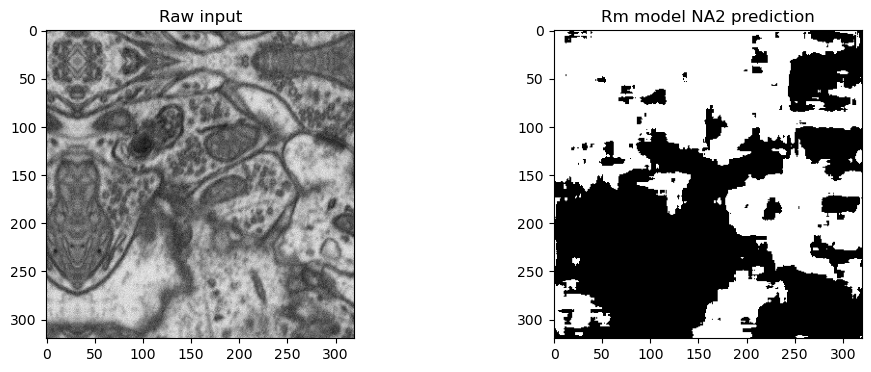

In [10]:
raw, label = dataset[0]
_, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].imshow(raw.numpy().squeeze(), cmap="gray")
axs[0].set_title("Raw input")
# axs[1].imshow(label.numpy().squeeze(), cmap="gray")
# axs[1].set_title("Ground truth")
axs[1].imshow(prediction[0].numpy().squeeze(), cmap="gray")
axs[1].set_title("Rm model NA2 prediction")
plt.show()

In [11]:
gt_path = "/scratch/talks/data/EPFL/test.h5"
EPFL_gt = load_h5(gt_path, "labels")

In [12]:
pred_path = "/g/kreshuk/talks/model_ranking/notebooks/model_selection/consistency/mitochondria/predictions/test_predictions.h5"
pred_RtoE = load_h5(pred_path, "predictions")
patch_indexes = load_h5(pred_path, "patch_index")

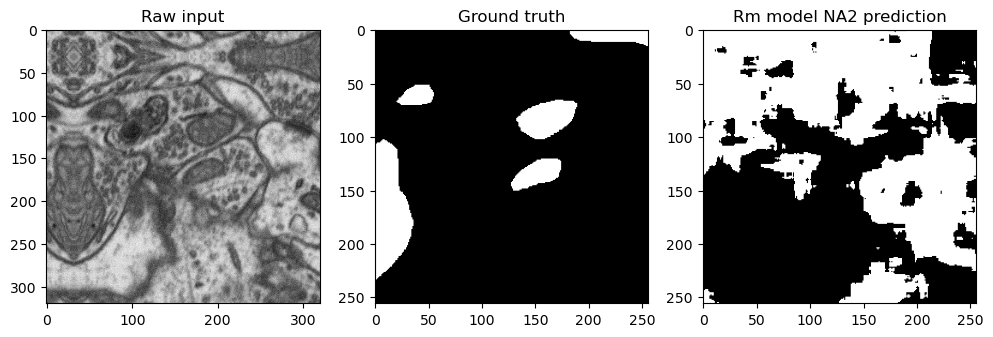

In [13]:

gt_patch_roi = get_roi_slice(patch_indexes[0])
gt_patch = EPFL_gt[gt_patch_roi]
_, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(raw.numpy().squeeze(), cmap="gray")
axs[0].set_title("Raw input")
axs[1].imshow(gt_patch.squeeze(), cmap="gray")
axs[1].set_title("Ground truth")
axs[2].imshow(pred_RtoE[0].squeeze()>0.5, cmap="gray")
axs[2].set_title("Rm model NA2 prediction")
plt.show()

# Direct use of predictor

In [14]:
gt_path = "/scratch/talks/data/EPFL/test.h5"
EPFL_gt = load_h5(gt_path, "labels")

In [15]:
# device = torch.device("cuda:0")
# RtoE_NA_model = RtoE_NA_model.to(device)
predictor = PatchWisePredictor(
    model=RtoE_NA_model,
    output_dir = "/g/kreshuk/talks/model_ranking/notebooks/model_selection/consistency/mitochondria/predictions/direct_predictor",
    out_channels=1,
)

In [16]:
predictor(dataloader)

2025-11-01 20:19:40,909 [MainThread] INFO UNetPredictor - Processing '/scratch/talks/data/EPFL/test.h5'...
2025-11-01 20:19:40,910 [MainThread] INFO UNetPredictor - Running inference on 75 batches
2025-11-01 20:19:40,911 [MainThread] INFO UNetPredictor - The shape of the output prediction maps (Number of patches, C, D, H, W): (750, 1, 1, 256, 256)
2025-11-01 20:19:40,913 [MainThread] INFO UNetPredictor - Allocating prediction arrays...


100%|██████████| 75/75 [00:02<00:00, 27.57it/s]

2025-11-01 20:19:43,637 [MainThread] INFO UNetPredictor - Finished inference in 2.73 seconds
2025-11-01 20:19:43,638 [MainThread] INFO UNetPredictor - Saving output to: /g/kreshuk/talks/model_ranking/notebooks/model_selection/consistency/mitochondria/predictions/direct_predictor/test_predictions.h5


In [17]:
pred_path = "/g/kreshuk/talks/model_ranking/notebooks/model_selection/consistency/mitochondria/predictions/direct_predictor/test_predictions.h5"
pred_RtoE = load_h5(pred_path, "predictions")
patch_indexes = load_h5(pred_path, "patch_index")

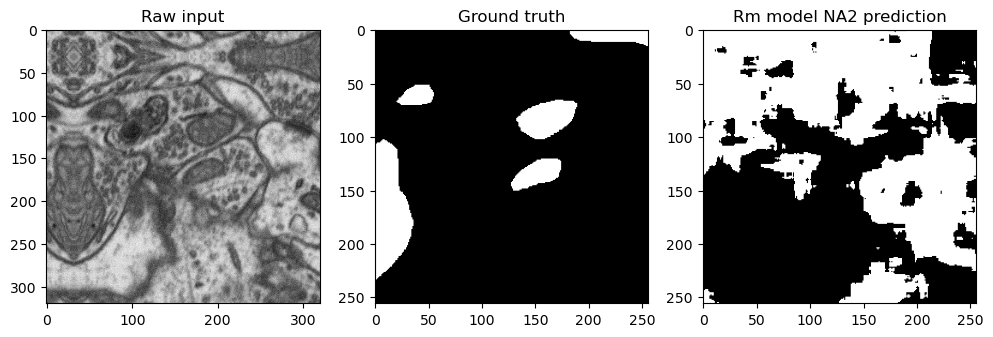

In [18]:
gt_patch_roi = get_roi_slice(patch_indexes[0])
gt_patch = EPFL_gt[gt_patch_roi]
_, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(raw.numpy().squeeze(), cmap="gray")
axs[0].set_title("Raw input")
axs[1].imshow(gt_patch.squeeze(), cmap="gray")
axs[1].set_title("Ground truth")
axs[2].imshow(pred_RtoE[0].squeeze()>0.5, cmap="gray")
axs[2].set_title("Rm model NA2 prediction")
plt.show()

## test yaml loader

In [19]:
from pytorch3dunet.datasets.utils import get_test_loaders

In [20]:
from typing import Any
yaml_config: Dict[str, Any] = {
    "device": "cuda:0",
    "loaders": {
        "dataset": "StandardHDF5Dataset",
        "batch_size": 1,
        "num_workers": 2,
        "raw_internal_path": "raw",
        "label_internal_path": "labels",
        "global_normalization": True,
        "global_percentiles": None,
        "output_dir": "/g/kreshuk/talks/model_ranking/notebooks/model_selection/consistency/mitochondria/predictions",
        "test": {
            "file_paths": ["/scratch/talks/data/EPFL/test.h5"],
            "slice_builder": {
                "name": "SliceBuilder",
                "patch_shape": [1, 256, 256],
                "stride_shape": [1, 256, 256],
                "halo_shape": [0, 32, 32]
            },
            "transformer": {
                "raw": [
                    {"name": "Normalize"},
                    {"name": "ToTensor", "expand_dims": True}
                ]
            },
            "roi": None
        }
    }
}

In [21]:
for loader in get_test_loaders(yaml_config):
    dataloader = loader

2025-11-01 20:20:01,363 [MainThread] INFO Dataset - Creating test set loaders...
2025-11-01 20:20:01,364 [MainThread] INFO HDF5Dataset - Loading test set from: /scratch/talks/data/EPFL/test.h5...
2025-11-01 20:20:01,366 [MainThread] INFO HDF5Dataset - Auto-calculated padding: [0, 0, 0] for patch_shape: [1, 256, 256] and volume_shape: (125, 480, 640)
2025-11-01 20:20:01,367 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 0.5599145293235779, global std: 0.11937469989061356
2025-11-01 20:20:01,576 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': [1, 256, 256], 'stride_shape': [1, 256, 256], 'halo_shape': [0, 32, 32]}
2025-11-01 20:20:01,577 [MainThread] INFO HDF5Dataset - Number of patches: 750
2025-11-01 20:20:01,578 [MainThread] INFO Dataset - Number of workers for the dataloader: 2
2025-11-01 20:20:01,579 [MainThread] INFO Dataset - 8 GPUs available. Using batch_size = 8 * 1
2025-11-01 20:20:01,579 [MainT

In [22]:
predictor = PatchWisePredictor(
    model=RtoE_NA_model,
    output_dir = "/g/kreshuk/talks/model_ranking/notebooks/model_selection/consistency/mitochondria/predictions/predictor_test_loader",
    out_channels=1,
)

In [23]:
predictor(dataloader)

2025-11-01 20:20:05,670 [MainThread] INFO UNetPredictor - Processing '/scratch/talks/data/EPFL/test.h5'...
2025-11-01 20:20:05,671 [MainThread] INFO UNetPredictor - Running inference on 94 batches
2025-11-01 20:20:05,671 [MainThread] INFO UNetPredictor - The shape of the output prediction maps (Number of patches, C, D, H, W): (750, 1, 1, 256, 256)
2025-11-01 20:20:05,689 [MainThread] INFO UNetPredictor - Allocating prediction arrays...


100%|██████████| 94/94 [00:02<00:00, 33.54it/s]

2025-11-01 20:20:08,495 [MainThread] INFO UNetPredictor - Finished inference in 2.82 seconds
2025-11-01 20:20:08,495 [MainThread] INFO UNetPredictor - Saving output to: /g/kreshuk/talks/model_ranking/notebooks/model_selection/consistency/mitochondria/predictions/predictor_test_loader/test_predictions.h5


In [24]:
pred_path = "/g/kreshuk/talks/model_ranking/notebooks/model_selection/consistency/mitochondria/predictions/predictor_test_loader/test_predictions.h5"
pred_RtoE = load_h5(pred_path, "predictions")
patch_indexes = load_h5(pred_path, "patch_index")

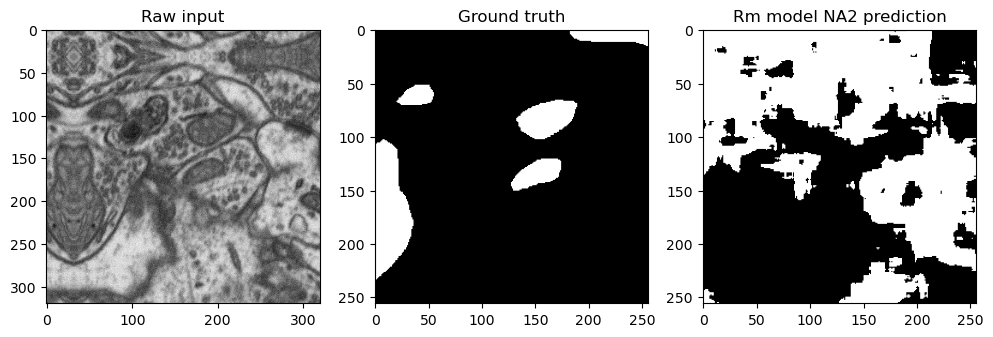

In [25]:
gt_patch_roi = get_roi_slice(patch_indexes[0])
gt_patch = EPFL_gt[gt_patch_roi]
_, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(raw.numpy().squeeze(), cmap="gray")
axs[0].set_title("Raw input")
axs[1].imshow(gt_patch.squeeze(), cmap="gray")
axs[1].set_title("Ground truth")
axs[2].imshow(pred_RtoE[0].squeeze()>0.5, cmap="gray")
axs[2].set_title("Rm model NA2 prediction")
plt.show()